In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from imblearn.over_sampling import SMOTE

# Plot styling
sns.set_theme(style="whitegrid")

Dataset Shape: (284807, 31)
Missing Values: 0

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud Percentage: 0.1727%


C:\Users\Hassaan\AppData\Local\Temp\ipykernel_14704\3939000790.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Blues_r')


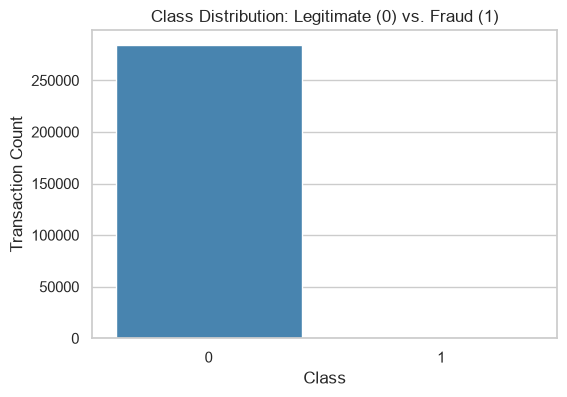

In [9]:
df = pd.read_csv('creditcard.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().max()}")

class_counts = df['Class'].value_counts()
fraud_pct = (class_counts[1] / len(df)) * 100

print(f"\nClass Distribution:\n{class_counts}")
print(f"Fraud Percentage: {fraud_pct:.4f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Blues_r')
plt.title('Class Distribution: Legitimate (0) vs. Fraud (1)')
plt.xlabel('Class')
plt.ylabel('Transaction Count')
plt.show()

In [10]:
# Scale Time and Amount using RobustScaler (handles outliers robustly)
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified Split (80% train, 20% test) to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape} | Fraud instances: {y_train.sum()}")
print(f"Testing shape:  {X_test.shape}  | Fraud instances: {y_test.sum()}")

Training shape: (227845, 30) | Fraud instances: 394
Testing shape:  (56962, 30)  | Fraud instances: 98


In [11]:
# Apply SMOTE strictly on training set to avoid data leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original Training Distribution: {y_train.value_counts().to_dict()}")
print(f"Resampled Training Distribution: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Original Training Distribution: {0: 227451, 1: 394}
Resampled Training Distribution: {0: 227451, 1: 227451}


In [12]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0     0.9999    0.9748    0.9872     56864
           1     0.0591    0.9184    0.1110        98

    accuracy                         0.9747     56962
   macro avg     0.5295    0.9466    0.5491     56962
weighted avg     0.9982    0.9747    0.9857     56962

ROC-AUC Score: 0.9712


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest Results ===
              precision    recall  f1-score   support

           0     0.9998    0.9977    0.9987     56864
           1     0.3925    0.8571    0.5385        98

    accuracy                         0.9975     56962
   macro avg     0.6961    0.9274    0.7686     56962
weighted avg     0.9987    0.9975    0.9979     56962

ROC-AUC Score: 0.9844


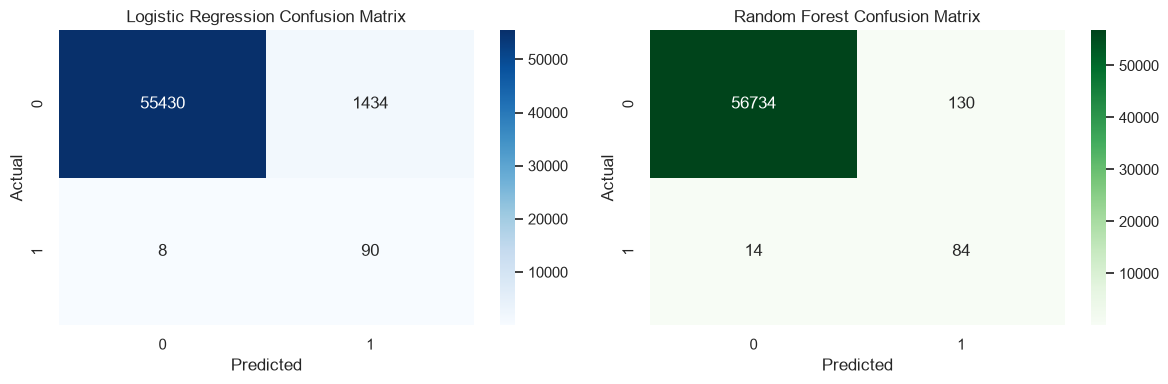

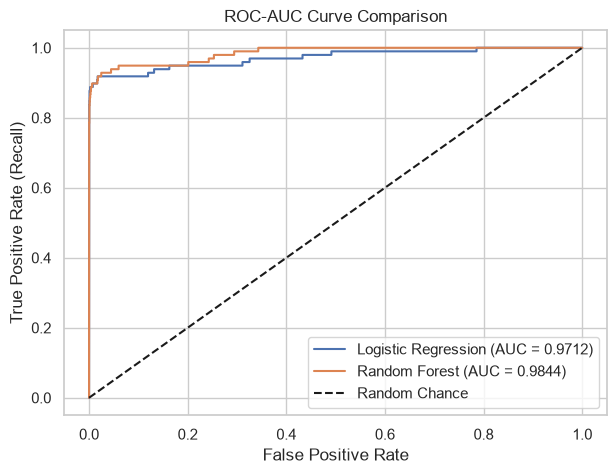

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-AUC Curve Comparison')
plt.legend()
plt.show()